# La rendija de Young, encogida siete órdenes de magnitud

**1,36 ångströms.** Esa es la separación entre las dos "rendijas" de este experimento: dos columnas vecinas de átomos de silicio, dentro de un cristal. Un haz de electrones enfocado cubre las dos a la vez y sale con franjas de interferencia — el experimento de Young de 1801, pero con rendijas que además **vibran**.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** Tabata et al. (2026), *Nature* — *Atomic-scale double-slit interferometry with a focused electron probe*
**DOI:** [10.1038/s41586-026-10914-9](https://doi.org/10.1038/s41586-026-10914-9)
**Datos:** [Zenodo 10.5281/zenodo.18189080](https://doi.org/10.5281/zenodo.18189080) (CC BY 4.0)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-08-19-doble-rendija-atomica-silicio/notebook.ipynb)

**Video:** [Ver en YouTube](https://youtube.com/shorts/TRGSfrMh43A)

## Qué montaron

El microscopio es un STEM (microscopio electrónico de transmisión de barrido): dispara electrones a 300 kV y los enfoca en una sonda de 1,1 Å de ancho a media altura. Esa sonda es **más ancha que el hueco entre las dos columnas de silicio**, así que no ilumina una u otra — las cubre a las dos, y por eso hay interferencia.

Detrás de la muestra, un detector recoge hacia dónde salió cada electrón. Sumando 356 pares de columnas equivalentes juntaron unos 33 millones de electrones por patrón, y repitieron la medida calentando la muestra dentro del microscopio a 300, 500 y 900 K.

El equipo publicó las salidas de sus figuras: los patrones medidos, los paisajes de error del ajuste y el cálculo de vibraciones de la red. **Eso es lo que exploramos acá** — no volvemos a correr sus simulaciones, que necesitan GPU y horas de cómputo.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
TEMPERATURAS   = [300, 500, 900]   # K — las tres medidas del experimento
T_FOCO         = 300               # K — temperatura del paisaje de error que miramos en detalle
VENTANA_MRAD   = 12.0              # mrad — media ventana angular al mostrar los patrones
TOP_FRACCION   = 0.10              # fracción de modos "top" al medir concentración

COLOR_DATOS       = '#2563EB'   # azul CaM
COLOR_ALERTA      = '#DC2626'   # rojo
COLOR_SECUNDARIO  = '#059669'   # emerald
COLOR_REFERENCIA  = '#D97706'   # amber
COLOR_CONTEXTO    = '#BBBBBB'   # gris

FUENTE = ('Fuente: Tabata et al. (2026), Nature | '
          'Datos: Zenodo 10.5281/zenodo.18189080 (CC BY 4.0)')

# ── Setup ─────────────────────────────────────────────────────
import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE = ('https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/'
        'papers/2026-08-19-doble-rendija-atomica-silicio')

# Estilo CaM (local → fallback a GitHub raw)
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle'.replace(
            '/papers/2026-08-19-doble-rendija-atomica-silicio', ''), style_file)
plt.style.use(style_file)

# Descarga automática de los datos si faltan
ARCHIVOS = ['correlaciones_temperatura.csv', 'cbed_experimental.csv',
            'dispersion_fonones.csv', 'gamma_desplazamiento_relativo.csv',
            'mse_landscape_300k.csv', 'mse_landscape_500k.csv',
            'mse_landscape_900k.csv', 'perfil_radial_cbed.csv',
            'cbed_exp_300k.npy', 'cbed_exp_500k.npy', 'cbed_exp_900k.npy']
os.makedirs('datos', exist_ok=True)
for nombre in ARCHIVOS:
    destino = f'datos/{nombre}'
    if not os.path.exists(destino):
        urllib.request.urlretrieve(f'{BASE}/datos/{nombre}', destino)

# ── Carga ─────────────────────────────────────────────────────
corr  = pd.read_csv('datos/correlaciones_temperatura.csv').set_index('temperatura_K')
meta  = pd.read_csv('datos/cbed_experimental.csv').set_index('temperatura_K')
disp  = pd.read_csv('datos/dispersion_fonones.csv')
gamma = pd.read_csv('datos/gamma_desplazamiento_relativo.csv')
paisajes = {T: pd.read_csv(f'datos/mse_landscape_{T}k.csv') for T in TEMPERATURAS}
patrones = {T: np.load(f'datos/cbed_exp_{T}k.npy').astype(float) for T in TEMPERATURAS}

# Peso vibracional por modo: suma de las dos componentes del proxy MSRD
disp['peso'] = disp['peso_msrd_x'] + disp['peso_msrd_y']

print('Patrones medidos      :', {T: patrones[T].shape for T in TEMPERATURAS})
for T in TEMPERATURAS:
    print(f'  {T} K -> {patrones[T].sum():,.0f} electrones'.replace(',', '.'),
          f'| {meta.loc[T, "mrad_por_px"]:.3f} mrad/pixel',
          f'| espesor {corr.loc[T, "espesor_nm"]} nm')
print()
print(f'Paisajes de error     : {len(paisajes[T_FOCO])} celdas '
      f'({paisajes[T_FOCO].rho_x.nunique()}x{paisajes[T_FOCO].rho_y.nunique()}) por temperatura')
print(f'Modos de vibración    : {len(disp):,}'.replace(',', '.'),
      f'= {disp.q_distancia.nunique()} puntos del recorrido x {disp.rama.nunique()} ramas')
print(f'Ramas en el punto Gamma: {len(gamma)} '
      f'({(gamma.tipo == "acustica").sum()} acústicas, {(gamma.tipo == "optica").sum()} ópticas)')

Patrones medidos      : {300: (182, 182), 500: (182, 182), 900: (182, 182)}
  300 K -> 33.127.287 electrones | 0.642 mrad/pixel | espesor 12.7 nm
  500 K -> 34.378.867 electrones | 0.621 mrad/pixel | espesor 10.8 nm
  900 K -> 34.241.580 electrones | 0.756 mrad/pixel | espesor 10.4 nm

Paisajes de error     : 1681 celdas (41x41) por temperatura
Modos de vibración    : 9.696 = 808 puntos del recorrido x 12 ramas
Ramas en el punto Gamma: 12 (3 acústicas, 9 ópticas)


Aquí está.

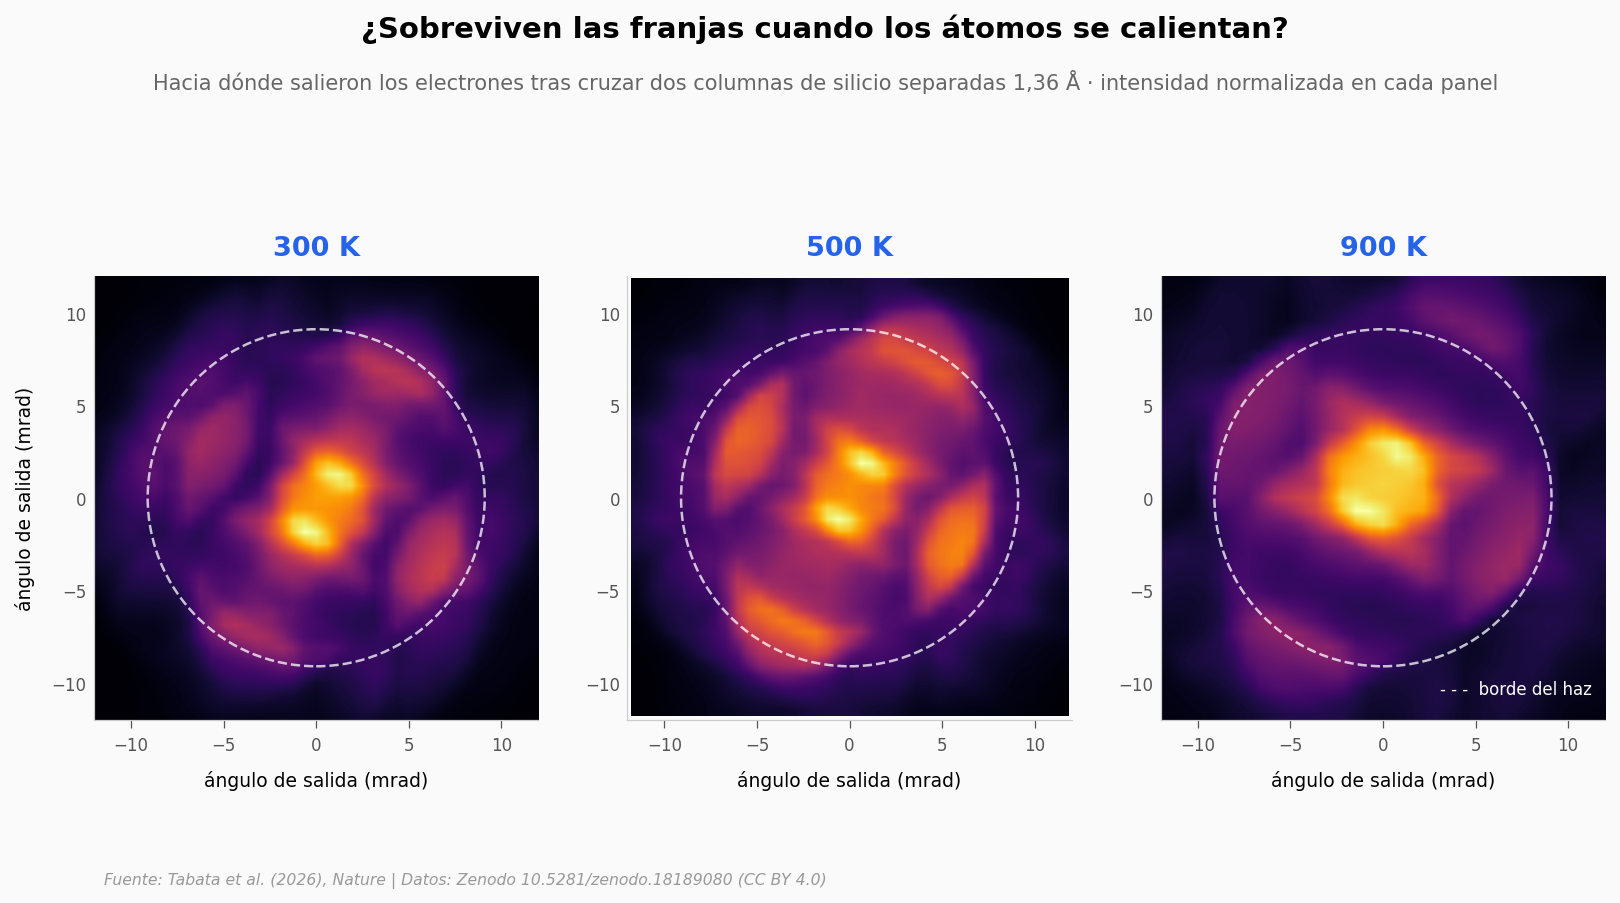

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(13, 5.0))

for ax, T in zip(axes, TEMPERATURAS):
    patron = patrones[T]
    mrad_px = meta.loc[T, 'mrad_por_px']
    radio_disco = meta.loc[T, 'radio_disco_px'] * mrad_px

    # Centro de masa del patrón (el haz no cae exactamente en el pixel central)
    n = patron.shape[0]
    yy, xx = np.mgrid[:n, :n]
    cy = (patron * yy).sum() / patron.sum()
    cx = (patron * xx).sum() / patron.sum()

    medio_px = int(round(VENTANA_MRAD / mrad_px))
    y0, x0 = int(round(cy)), int(round(cx))
    recorte = patron[y0 - medio_px:y0 + medio_px + 1,
                     x0 - medio_px:x0 + medio_px + 1]
    lim = medio_px * mrad_px
    ax.imshow(recorte / recorte.max(), cmap='inferno', origin='lower',
              extent=[-lim, lim, -lim, lim], vmin=0, vmax=1, interpolation='bilinear')
    ax.add_patch(plt.Circle((0, 0), radio_disco, fill=False, color='white',
                            lw=1.2, ls='--', alpha=0.75))
    ax.grid(False)
    ax.set_xlim(-VENTANA_MRAD, VENTANA_MRAD)
    ax.set_ylim(-VENTANA_MRAD, VENTANA_MRAD)
    ax.set_title(f'{T} K', fontsize=13, fontweight='bold', color=COLOR_DATOS, pad=10)
    ax.set_xlabel('ángulo de salida (mrad)', fontsize=9)
    ax.tick_params(labelsize=8)

axes[0].set_ylabel('ángulo de salida (mrad)', fontsize=9)
axes[2].text(0.97, 0.05, '- - -  borde del haz', transform=axes[2].transAxes,
             fontsize=8, color='white', ha='right', va='bottom')

fig.suptitle('¿Sobreviven las franjas cuando los átomos se calientan?',
             fontsize=14, fontweight='bold', y=1.14)
fig.text(0.5, 1.04, 'Hacia dónde salieron los electrones tras cruzar dos columnas de silicio '
                    'separadas 1,36 Å · intensidad normalizada en cada panel',
         fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/franjas_por_temperatura.png', dpi=200, bbox_inches='tight')
plt.show()

## Lo que hay que mirar

Ese par de manchas brillantes pegadas en el centro es la firma de las dos columnas: el electrón no eligió una, pasó por las dos y el resultado depende de la diferencia de camino. A 900 K la estructura interna sigue ahí, aunque se lee más difusa — el equipo reporta que las franjas persisten en todo el rango de 300 K a 900 K.

Y eso es raro. A 900 K cada átomo de silicio se está moviendo un 62,5% más que a 300 K (el desplazamiento típico pasa de 0,08 a 0,13 Å, sobre un hueco de apenas 1,36 Å). Con rendijas temblando así de fuerte, lo esperable sería que el patrón se borrara.

La explicación del paper es que **las dos columnas no tiemblan cada una por su lado**. Si se mueven juntas, la distancia entre ellas cambia mucho menos que la posición de cada una — y esa distancia es lo que fija las franjas.

Todo el trabajo cuantitativo del paper es ponerle número a ese "juntas". Se resume en dos coeficientes de correlación: **ρₓ** para el movimiento a lo largo de la línea que une las columnas, y **ρᵧ** para el movimiento perpendicular. Cero significa que cada columna hace lo que quiere; uno, que van perfectamente pegadas.

¿Cómo se miden? Probando. Para cada combinación de (ρₓ, ρᵧ) se simula el patrón que saldría y se compara con el medido. La combinación que menos error deja es la respuesta.

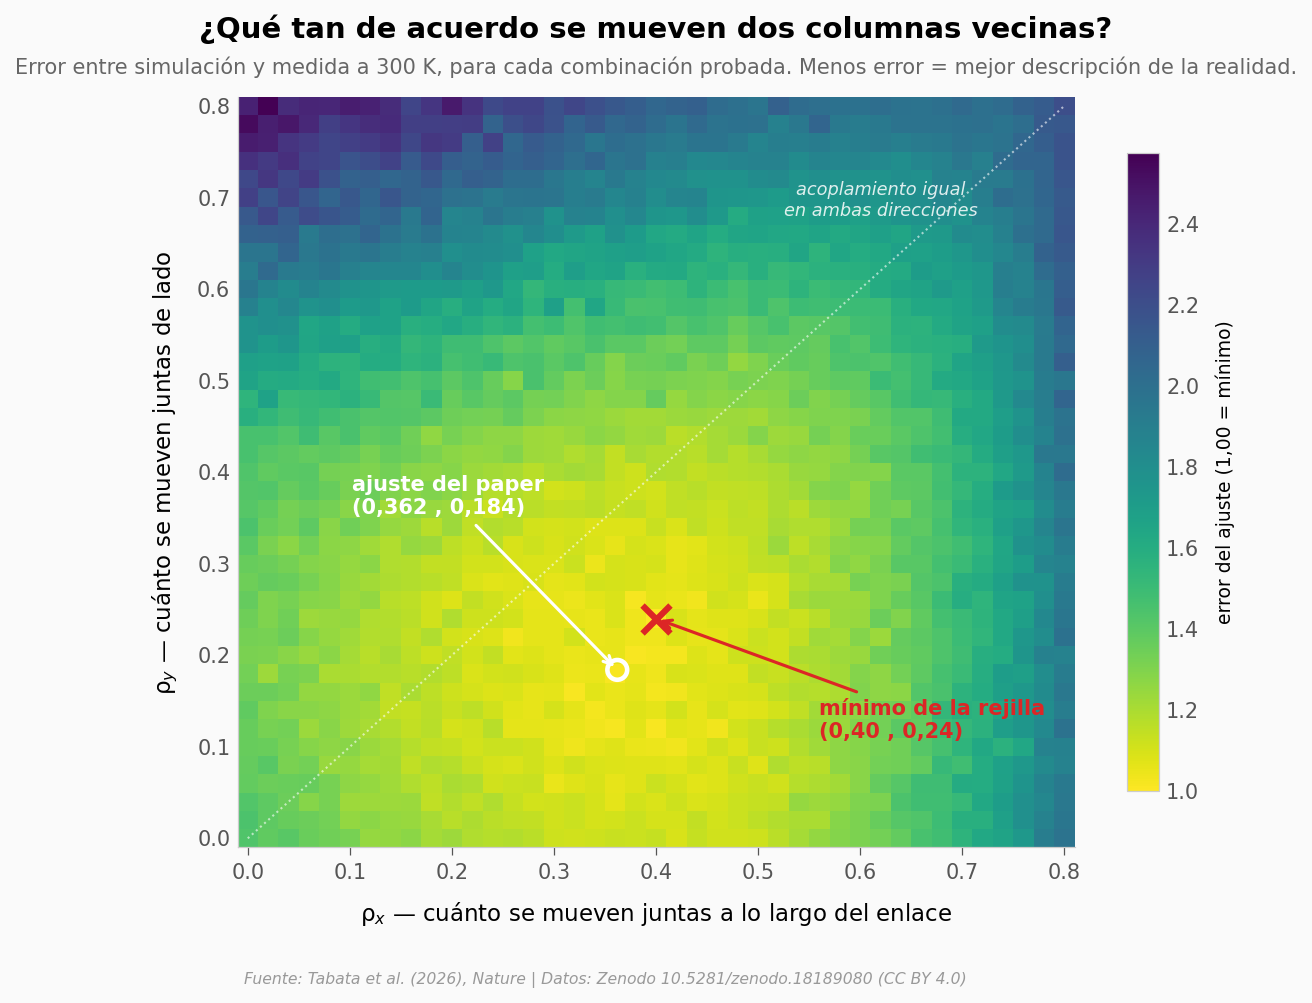

300 K — mínimo de rejilla: rho_x = 0.40, rho_y = 0.24
300 K — ajuste del paper : rho_x = 0.362 ± 0.005, rho_y = 0.184 ± 0.005

Qué tan definido está el mínimo, temperatura por temperatura:
  300 K -> mínimo en (0.40 , 0.24) |  5 de 1681 celdas dentro del 2% del mínimo | ajuste del paper (0.362 , 0.184)
  500 K -> mínimo en (0.40 , 0.26) | 10 de 1681 celdas dentro del 2% del mínimo | ajuste del paper (0.402 , 0.263)
  900 K -> mínimo en (0.46 , 0.36) | 89 de 1681 celdas dentro del 2% del mínimo | ajuste del paper (0.418 , 0.288)


In [3]:
fig, ax = plt.subplots(figsize=(9, 6.5))

p = paisajes[T_FOCO]
rho_x = np.sort(p.rho_x.unique())
rho_y = np.sort(p.rho_y.unique())
malla = p.pivot(index='rho_y', columns='rho_x', values='mse').values

# El error se muestra relativo a su mínimo: 1,00 = mejor ajuste posible
malla_rel = malla / malla.min()

mapa = ax.pcolormesh(rho_x, rho_y, malla_rel, cmap='viridis_r', shading='nearest')
cbar = plt.colorbar(mapa, ax=ax, shrink=0.85)
cbar.set_label('error del ajuste (1,00 = mínimo)', fontsize=9)

# Mínimo de la rejilla (lo que calculamos nosotros)
i_min = p.mse.idxmin()
mx, my = p.loc[i_min, 'rho_x'], p.loc[i_min, 'rho_y']
ax.scatter([mx], [my], marker='x', s=180, color=COLOR_ALERTA, linewidths=3, zorder=6)
ax.annotate(f'mínimo de la rejilla\n({mx:.2f} , {my:.2f})'.replace('.', ','),
            xy=(mx, my), xytext=(mx + 0.16, my - 0.13),
            fontsize=10, fontweight='bold', color=COLOR_ALERTA,
            arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.5))

# Ajuste publicado por el equipo (interpolado entre celdas)
px, py = corr.loc[T_FOCO, 'rho_x_paper'], corr.loc[T_FOCO, 'rho_y_paper']
ax.scatter([px], [py], marker='o', s=90, facecolor='none',
           edgecolor='white', linewidths=2.2, zorder=6)
ax.annotate(f'ajuste del paper\n({px:.3f} , {py:.3f})'.replace('.', ','),
            xy=(px, py), xytext=(px - 0.26, py + 0.17),
            fontsize=10, fontweight='bold', color='white',
            arrowprops=dict(arrowstyle='->', color='white', lw=1.5))

# Diagonal: movimiento igual de acoplado en las dos direcciones
ax.plot([0, 0.8], [0, 0.8], color='white', lw=1, ls=':', alpha=0.6)
ax.text(0.62, 0.68, 'acoplamiento igual\nen ambas direcciones', fontsize=8.5,
        color='white', ha='center', style='italic', alpha=0.85)

ax.set_xlabel('ρ$_x$ — cuánto se mueven juntas a lo largo del enlace', fontsize=11)
ax.set_ylabel('ρ$_y$ — cuánto se mueven juntas de lado', fontsize=11)
ax.set_title('¿Qué tan de acuerdo se mueven dos columnas vecinas?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, f'Error entre simulación y medida a {T_FOCO} K, para cada combinación probada. '
                   'Menos error = mejor descripción de la realidad.',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.grid(False)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/paisaje_correlacion.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'{T_FOCO} K — mínimo de rejilla: rho_x = {mx:.2f}, rho_y = {my:.2f}')
print(f'{T_FOCO} K — ajuste del paper : rho_x = {px:.3f} ± {corr.loc[T_FOCO, "rho_x_ic95"]:.3f}, '
      f'rho_y = {py:.3f} ± {corr.loc[T_FOCO, "rho_y_ic95"]:.3f}')
print()
print('Qué tan definido está el mínimo, temperatura por temperatura:')
for t in TEMPERATURAS:
    pt = paisajes[t]
    j = pt.mse.idxmin()
    n_cerca = (pt.mse <= pt.mse.min() * 1.02).sum()
    print(f'  {t} K -> mínimo en ({pt.loc[j, "rho_x"]:.2f} , {pt.loc[j, "rho_y"]:.2f})'
          f' | {n_cerca:>2} de {len(pt)} celdas dentro del 2% del mínimo'
          f' | ajuste del paper ({corr.loc[t, "rho_x_paper"]:.3f} , {corr.loc[t, "rho_y_paper"]:.3f})')

## El detalle que no encaja con la intuición

El mínimo está claramente **abajo de la diagonal**: ρₓ es mayor que ρᵧ. Las dos columnas se acompañan más cuando se acercan y se alejan entre sí que cuando se desplazan de lado. Tiene sentido físico — el enlace Si–Si de 2,35 Å resiste el estiramiento mucho mejor que la torsión.

Ahora, la parte contraintuitiva. Si calentar agita más los átomos, ¿el acuerdo entre columnas debería romperse?

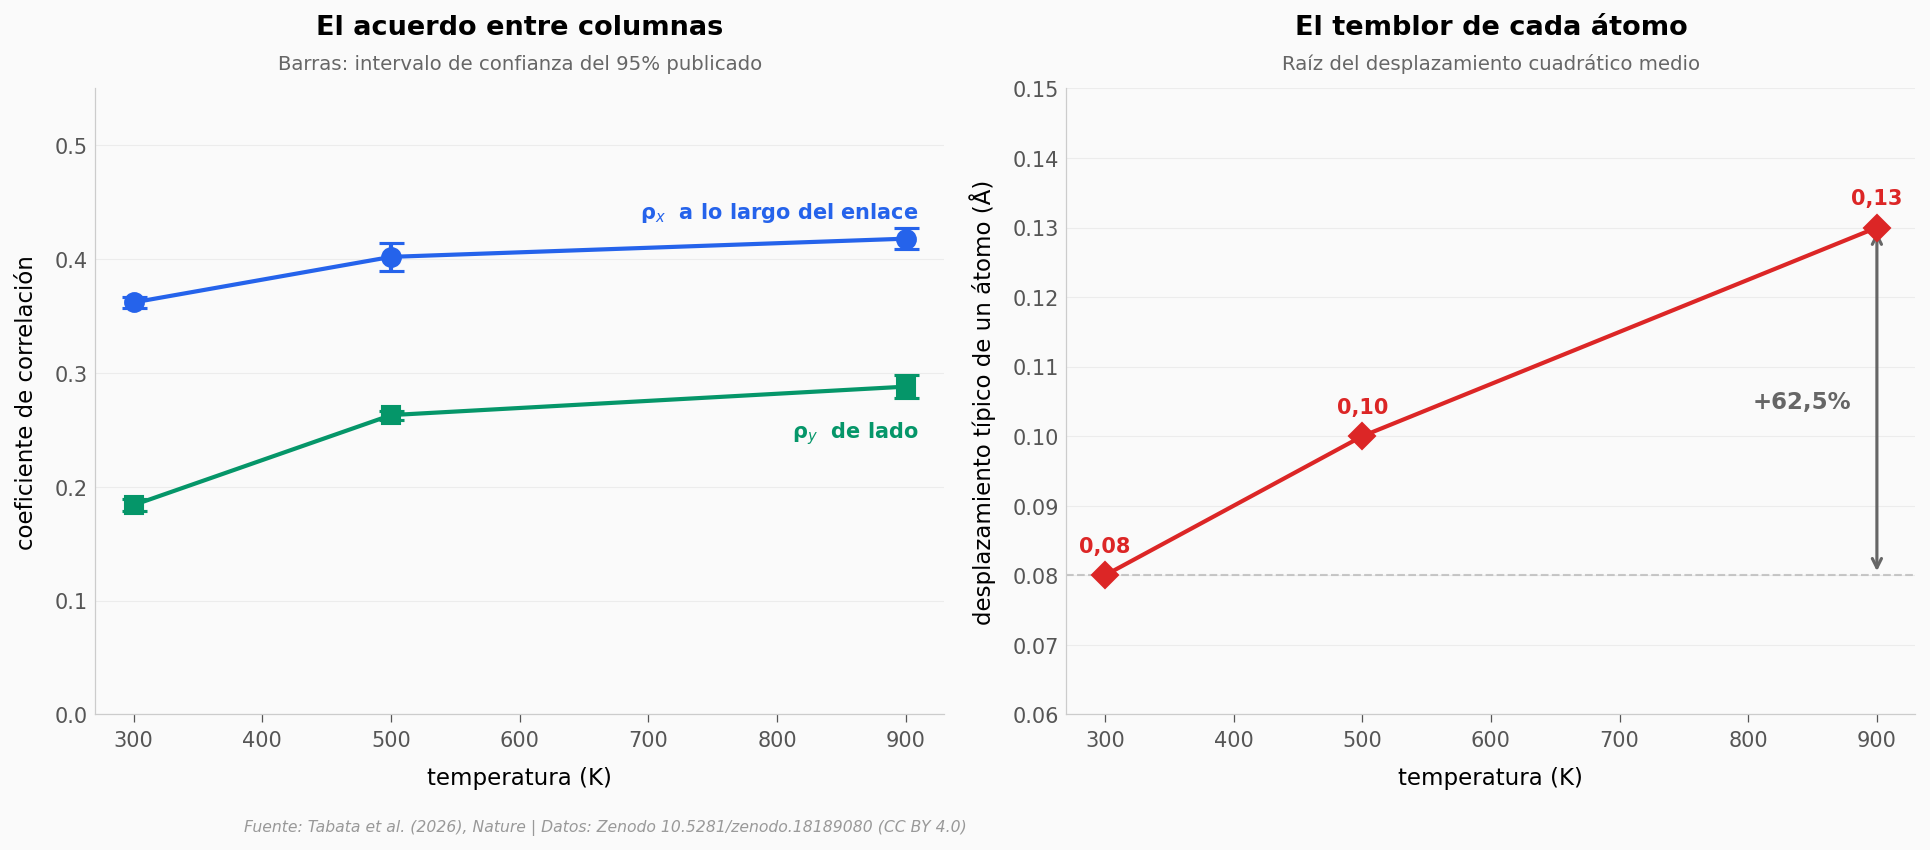

De 300 K a 900 K:
  rho_x: 0.362 -> 0.418  (+0.056)
  rho_y: 0.184 -> 0.288  (+0.104)
  desplazamiento por átomo: 0.08 -> 0.13 A  (+62.5%)

Rigidez relativa del enlace (kappa = rho / (1-rho)^2):
  300 K: a lo largo 0.889 | de lado 0.276 -> razón 3.22x
  500 K: a lo largo 1.124 | de lado 0.484 -> razón 2.32x
  900 K: a lo largo 1.234 | de lado 0.568 -> razón 2.17x


In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))

T = np.array(TEMPERATURAS)

# ── Panel izquierdo: los dos coeficientes con su intervalo de confianza ──
ax1.errorbar(T, corr.rho_x_paper, yerr=corr.rho_x_ic95, marker='o', markersize=9,
             color=COLOR_DATOS, lw=2, capsize=6, capthick=1.5, zorder=5)
ax1.errorbar(T, corr.rho_y_paper, yerr=corr.rho_y_ic95, marker='s', markersize=9,
             color=COLOR_SECUNDARIO, lw=2, capsize=6, capthick=1.5, zorder=5)
ax1.text(910, corr.rho_x_paper.iloc[-1] + 0.018, 'ρ$_x$  a lo largo del enlace',
         fontsize=10, color=COLOR_DATOS, fontweight='bold', ha='right')
ax1.text(910, corr.rho_y_paper.iloc[-1] - 0.045, 'ρ$_y$  de lado',
         fontsize=10, color=COLOR_SECUNDARIO, fontweight='bold', ha='right')
ax1.set_ylim(0, 0.55)
ax1.set_xlabel('temperatura (K)', fontsize=11)
ax1.set_ylabel('coeficiente de correlación', fontsize=11)
ax1.set_title('El acuerdo entre columnas', fontsize=13, fontweight='bold', pad=26)
ax1.text(0.5, 1.03, 'Barras: intervalo de confianza del 95% publicado',
         transform=ax1.transAxes, fontsize=9.5, color='#666666', ha='center')

# ── Panel derecho: cuánto se agita cada átomo por su cuenta ──
ax2.plot(T, corr.msd_A, marker='D', markersize=9, color=COLOR_ALERTA, lw=2, zorder=5)
for t, v in zip(T, corr.msd_A):
    ax2.annotate(f'{v:.2f}'.replace('.', ','), xy=(t, v), xytext=(0, 11),
                 textcoords='offset points', fontsize=10, color=COLOR_ALERTA,
                 fontweight='bold', ha='center')
subida = (corr.msd_A.iloc[-1] / corr.msd_A.iloc[0] - 1) * 100
ax2.annotate('', xy=(900, corr.msd_A.iloc[-1]), xytext=(900, corr.msd_A.iloc[0]),
             arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax2.text(880, (corr.msd_A.iloc[0] + corr.msd_A.iloc[-1]) / 2,
         f'+{subida:.1f}%'.replace('.', ','), fontsize=11, fontweight='bold',
         color='#666666', ha='right', va='center')
ax2.axhline(y=corr.msd_A.iloc[0], color=COLOR_CONTEXTO, lw=1, ls='--', alpha=0.8)
ax2.set_ylim(0.06, 0.15)
ax2.set_xlabel('temperatura (K)', fontsize=11)
ax2.set_ylabel('desplazamiento típico de un átomo (Å)', fontsize=11)
ax2.set_title('El temblor de cada átomo', fontsize=13, fontweight='bold', pad=26)
ax2.text(0.5, 1.03, 'Raíz del desplazamiento cuadrático medio',
         transform=ax2.transAxes, fontsize=9.5, color='#666666', ha='center')

fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/correlacion_vs_temperatura.png', dpi=200, bbox_inches='tight')
plt.show()

d_x = corr.rho_x_paper.iloc[-1] - corr.rho_x_paper.iloc[0]
d_y = corr.rho_y_paper.iloc[-1] - corr.rho_y_paper.iloc[0]
print(f'De 300 K a 900 K:')
print(f'  rho_x: {corr.rho_x_paper.iloc[0]:.3f} -> {corr.rho_x_paper.iloc[-1]:.3f}  ({d_x:+.3f})')
print(f'  rho_y: {corr.rho_y_paper.iloc[0]:.3f} -> {corr.rho_y_paper.iloc[-1]:.3f}  ({d_y:+.3f})')
print(f'  desplazamiento por átomo: {corr.msd_A.iloc[0]} -> {corr.msd_A.iloc[-1]} A  ({subida:+.1f}%)')
print()
print('Rigidez relativa del enlace (kappa = rho / (1-rho)^2):')
for t in TEMPERATURAS:
    print(f'  {t} K: a lo largo {corr.loc[t, "kappa_x"]:.3f} | de lado {corr.loc[t, "kappa_y"]:.3f}'
          f' -> razón {corr.loc[t, "ratio_kappa_xy"]:.2f}x')

## Por qué el temblor no borra las franjas

Los dos paneles cuentan historias distintas. Cada átomo se agita un 62,5% más al pasar de 300 K a 900 K. Pero el acuerdo entre columnas **no se desploma: sube un poco**. En la escala de 0 a 1 del coeficiente, ρₓ gana 0,056 y ρᵧ gana 0,104. El paper lo describe como una dependencia moderada de la temperatura, y eso es exactamente lo que se ve.

Traducido al enlace: a 300 K resiste 3,2 veces más el estiramiento que el corte lateral. A 900 K la razón baja a 2,2 — el enlace se vuelve un poco menos desigual, pero la jerarquía se mantiene.

Falta la pregunta de fondo: ¿por qué calentar no rompe la coordinación? Un cristal no vibra "en general" — vibra en modos, cada uno con su frecuencia y su forma. Calentar excita más modos, sí, pero todo apunta a que **no todos hacen el mismo daño**: solo importarían los que separan las dos columnas entre sí, mientras que los que mueven a las dos en bloque no cambiarían nada.

Hay un caso extremo que ayuda a verlo: el punto Γ, donde el cristal entero se mueve en bloque. Miremos qué pasa ahí, rama por rama.

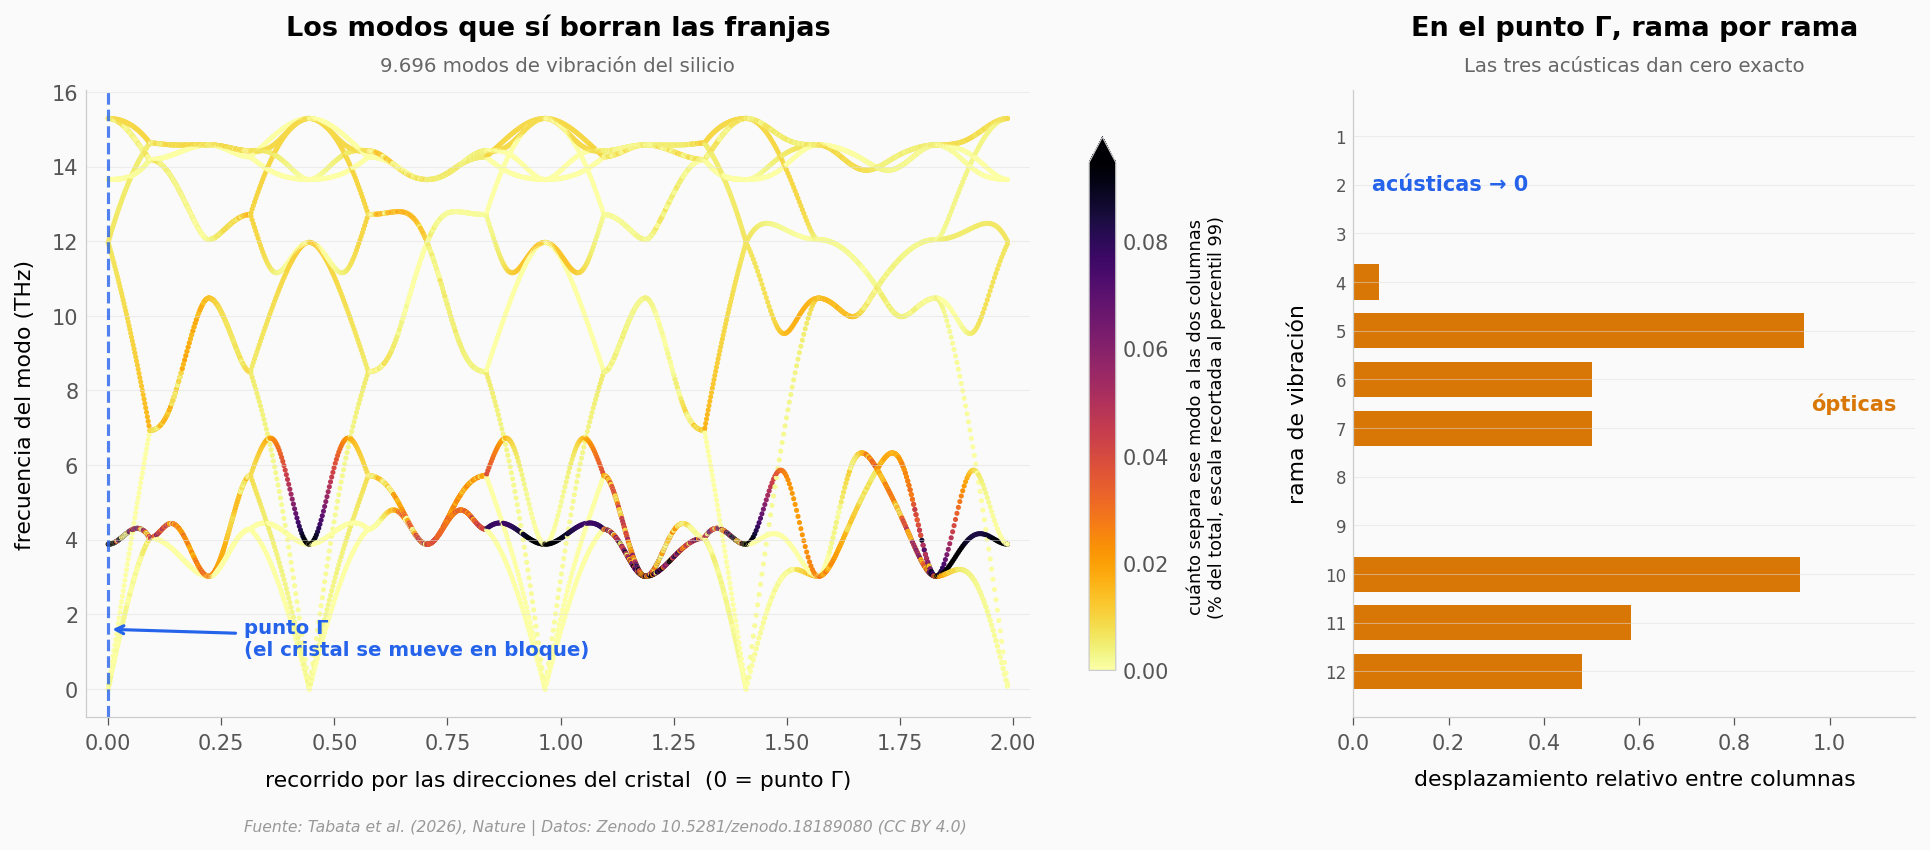

Punto Gamma — desplazamiento relativo de las ramas acústicas: [0.0, 0.0, 0.0]
Primer 10% del recorrido desde Gamma: 1104 modos (11.4% del total) aportan el 10.1% del peso
Ramas acústicas: 25.0% de los modos, 45.4% del peso


In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5),
                               gridspec_kw={'width_ratios': [2.1, 1]})

# ── Panel izquierdo: todos los modos, coloreados por cuánto separan las columnas ──
peso_rel = disp.peso / disp.peso.sum() * 100     # % del peso total, por modo
tope = np.percentile(peso_rel, 99)
sc = ax1.scatter(disp.q_distancia, disp.frecuencia_THz, c=peso_rel, cmap='inferno_r',
                 s=6, vmin=0, vmax=tope, linewidths=0)
cbar = plt.colorbar(sc, ax=ax1, shrink=0.85, extend='max')
cbar.set_label('cuánto separa ese modo a las dos columnas\n(% del total, escala recortada al percentil 99)',
               fontsize=8.5)

ax1.axvline(x=0, color=COLOR_DATOS, lw=1.5, ls='--', alpha=0.8)
ax1.annotate('punto Γ\n(el cristal se mueve en bloque)', xy=(0, 1.6), xytext=(0.30, 0.9),
             fontsize=9.5, fontweight='bold', color=COLOR_DATOS,
             arrowprops=dict(arrowstyle='->', color=COLOR_DATOS, lw=1.5))
ax1.set_xlabel('recorrido por las direcciones del cristal  (0 = punto Γ)', fontsize=10.5)
ax1.set_ylabel('frecuencia del modo (THz)', fontsize=10.5)
ax1.set_title('Los modos que sí borran las franjas', fontsize=13, fontweight='bold', pad=26)
ax1.text(0.5, 1.03, f'{len(disp):,} modos de vibración del silicio'.replace(',', '.'),
         transform=ax1.transAxes, fontsize=9.5, color='#666666', ha='center')
ax1.set_xlim(-0.05, disp.q_distancia.max() + 0.05)

# ── Panel derecho: el punto Gamma, rama por rama ──
colores = [COLOR_DATOS if t == 'acustica' else COLOR_REFERENCIA for t in gamma.tipo]
desplaz = gamma.desplaz_relativo_x + gamma.desplaz_relativo_y
ax2.barh(gamma.rama, desplaz, color=colores, height=0.72)
ax2.set_yticks(gamma.rama)
ax2.set_yticklabels([f'{r}' for r in gamma.rama], fontsize=8)
ax2.invert_yaxis()
ax2.set_xlabel('desplazamiento relativo entre columnas', fontsize=10.5)
ax2.set_ylabel('rama de vibración', fontsize=10.5)
ax2.set_title('En el punto Γ, rama por rama', fontsize=13, fontweight='bold', pad=26)
ax2.text(0.5, 1.03, 'Las tres acústicas dan cero exacto',
         transform=ax2.transAxes, fontsize=9.5, color='#666666', ha='center')
ax2.set_xlim(0, 1.18)
ax2.text(0.04, 2, 'acústicas → 0', fontsize=10, fontweight='bold',
         color=COLOR_DATOS, va='center')
ax2.text(1.14, 6.5, 'ópticas', fontsize=10, fontweight='bold',
         color=COLOR_REFERENCIA, va='center', ha='right')

fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/dispersion_fonones.png', dpi=200, bbox_inches='tight')
plt.show()

acus = gamma[gamma.tipo == 'acustica']
print('Punto Gamma — desplazamiento relativo de las ramas acústicas:',
      list(np.round(acus.desplaz_relativo_x + acus.desplaz_relativo_y, 12)))
cerca = disp.q_distancia <= 0.10 * disp.q_distancia.max()
print(f'Primer 10% del recorrido desde Gamma: {cerca.sum()} modos '
      f'({cerca.mean() * 100:.1f}% del total) aportan el '
      f'{disp[cerca].peso.sum() / disp.peso.sum() * 100:.1f}% del peso')
es_ac = disp.tipo == 'acustica'
print(f'Ramas acústicas: {es_ac.mean() * 100:.1f}% de los modos, '
      f'{disp[es_ac].peso.sum() / disp.peso.sum() * 100:.1f}% del peso')

## ¿Cuántos modos hacen el daño?

El cero en Γ es exacto y no depende de convenciones, pero cubre un solo punto del cristal. La pregunta útil es cómo se reparte el daño entre los 9.696 modos.

Hay una vara de medir obvia: si todos aportaran lo mismo, el 10% más dañino se llevaría exactamente el 10% del total. Veamos qué pasa de verdad.

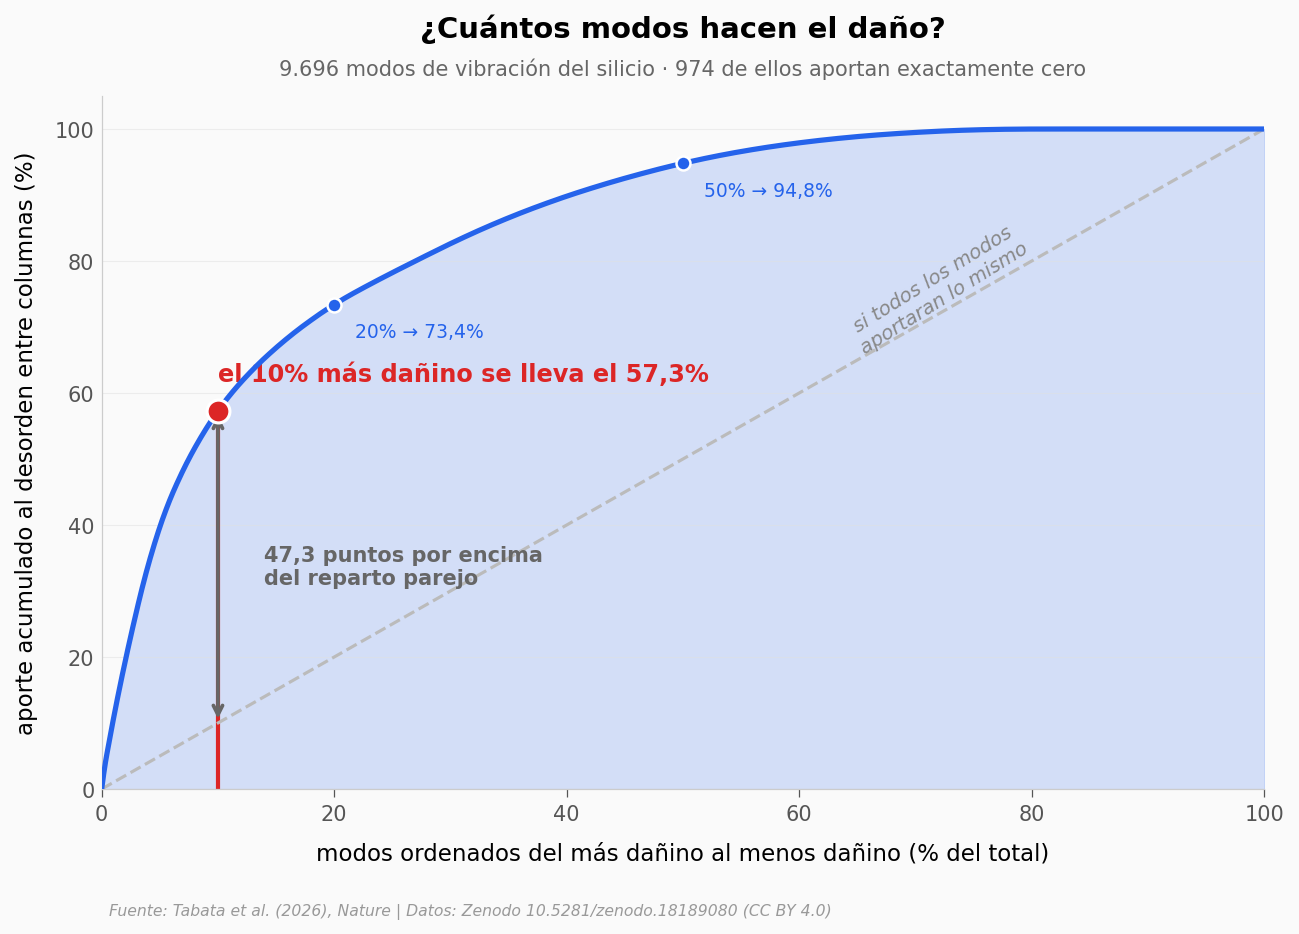

Concentración del aporte al desorden entre columnas:
  el   5% de los modos ( 485 de 9696) concentra  39.7% del total
  el  10% de los modos ( 970 de 9696) concentra  57.3% del total
  el  20% de los modos (1939 de 9696) concentra  73.4% del total
  el  50% de los modos (4848 de 9696) concentra  94.8% del total

Modos con aporte exactamente cero: 974 (10.0%)


In [6]:
fig, ax = plt.subplots(figsize=(10, 6))

# Modos ordenados del más dañino al menos dañino, y aporte acumulado
orden = np.sort((disp.peso / disp.peso.sum()).values)[::-1]
acumulado = np.cumsum(orden) * 100
eje_modos = np.arange(1, len(orden) + 1) / len(orden) * 100

ax.fill_between(eje_modos, 0, acumulado, color=COLOR_DATOS, alpha=0.18)
ax.plot(eje_modos, acumulado, color=COLOR_DATOS, lw=2.5, zorder=5)
ax.plot([0, 100], [0, 100], color=COLOR_CONTEXTO, lw=1.5, ls='--', zorder=3)
ax.text(72, 66, 'si todos los modos\naportaran lo mismo', fontsize=9.5,
        color='#888888', style='italic', ha='center', rotation=32)

# El punto de referencia: el TOP_FRACCION más dañino
x_top = TOP_FRACCION * 100
y_top = acumulado[int(round(TOP_FRACCION * len(orden))) - 1]
ax.axvline(x=x_top, color=COLOR_ALERTA, lw=2, ymax=y_top / 105)
ax.scatter([x_top], [y_top], s=120, color=COLOR_ALERTA, zorder=6,
           edgecolors='white', linewidths=1.5)
ax.annotate('', xy=(x_top, y_top), xytext=(x_top, x_top),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.8))
ax.text(x_top + 4, (y_top + x_top) / 2,
        f'{y_top - x_top:.1f} puntos por encima\ndel reparto parejo'.replace('.', ','),
        fontsize=10, fontweight='bold', color='#666666', va='center')
ax.text(x_top, y_top + 4.5,
        f'el {TOP_FRACCION:.0%} más dañino se lleva el {y_top:.1f}%'.replace('.', ','),
        fontsize=11.5, fontweight='bold', color=COLOR_ALERTA, ha='left')

# Otros puntos de referencia sobre la curva
ANCLAS = {0.20: (1.8, -5.0, 'left'), 0.50: (1.8, -5.0, 'left')}
for frac, (dx, dy, ha) in ANCLAS.items():
    k = int(round(frac * len(orden)))
    ax.scatter([frac * 100], [acumulado[k - 1]], s=45, color=COLOR_DATOS, zorder=6,
               edgecolors='white', linewidths=1.2)
    ax.text(frac * 100 + dx, acumulado[k - 1] + dy,
            f'{frac:.0%} → {acumulado[k - 1]:.1f}%'.replace('.', ','),
            fontsize=9, color=COLOR_DATOS, ha=ha)

ax.set_xlim(0, 100)
ax.set_ylim(0, 105)
ax.set_xlabel('modos ordenados del más dañino al menos dañino (% del total)', fontsize=11)
ax.set_ylabel('aporte acumulado al desorden entre columnas (%)', fontsize=11)
ax.set_title('¿Cuántos modos hacen el daño?', fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, f'{len(orden):,} modos de vibración del silicio'.replace(',', '.') +
        f' · {int((disp.peso == 0).sum())} de ellos aportan exactamente cero',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/concentracion_modos.png', dpi=200, bbox_inches='tight')
plt.show()

print('Concentración del aporte al desorden entre columnas:')
for frac in [0.05, 0.10, 0.20, 0.50]:
    k = int(round(frac * len(orden)))
    print(f'  el {frac:>4.0%} de los modos ({k:>4} de {len(orden)}) concentra '
          f'{acumulado[k - 1]:5.1f}% del total')
n_cero = int((disp.peso == 0).sum())
print(f'\nModos con aporte exactamente cero: {n_cero} ({n_cero / len(disp) * 100:.1f}%)')

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| Las franjas se generan entre dos columnas de silicio separadas 1,36 Å | ✅ | El paper lo afirma directamente ("*we demonstrate*"). El archivo de celda cristalina que acompaña al cálculo de vibraciones da 1,3575 Å de separación proyectada — coincide dentro del redondeo |
| El patrón de 300 K reúne unos 33 millones de electrones | ✅ | El archivo medido suma 33.127.287 cuentas; el paper reporta 3,3 × 10⁷. Confirma que este archivo es el patrón publicado |
| Las franjas persisten de 300 K a 900 K | ⚠️ | Lo mostramos solo de forma **cualitativa**. Ni el paper ni el paquete de datos publican un número de visibilidad por temperatura, y medirlo requiere la geometría de máscara exacta que no viene incluida. Los tres patrones se ven, pero no cuantificamos la degradación |
| Las columnas se acompañan más a lo largo del enlace que de lado (ρₓ > ρᵧ) | ✅ | Se cumple en las tres temperaturas: 0,362 vs 0,184 (300 K), 0,402 vs 0,263 (500 K), 0,418 vs 0,288 (900 K) |
| Nuestro mínimo reproduce el ajuste del paper | ✅ | A 300 K y 500 K el mínimo de rejilla cae en (0,40 ; 0,24) y (0,40 ; 0,26), a menos de un paso de rejilla del ajuste publicado. El propio paper describe su figura como "*near ρₓ ~ 0,4 y ρᵧ ~ 0,2*" |
| El mínimo a 900 K también reproduce el ajuste | ⚠️ | Nuestro mínimo de rejilla es (0,46 ; 0,36) frente a (0,418 ; 0,288) del ajuste publicado. La razón está a la vista: a 900 K hay **89 celdas** dentro del 2% del mínimo, contra 5 a 300 K. El fondo del valle es tan plano que el mínimo de rejilla deja de ser informativo — el ajuste del paper interpola entre celdas |
| El átomo se agita un 62,5% más de 300 K a 900 K, y aun así el acuerdo entre columnas sube | ✅ | Desplazamiento típico 0,08 → 0,13 Å. Los coeficientes suben en absoluto (+0,056 y +0,104 sobre una escala de 0 a 1), consistente con la "dependencia moderada" que reporta el paper |
| El enlace resiste ~3 veces más el estiramiento que el corte | ✅ | Razón de rigideces 3,22 a 300 K, calculada como κ = ρ/(1−ρ)² sobre los coeficientes publicados. Baja a 2,17 a 900 K |
| En el punto Γ las tres ramas acústicas dan desplazamiento relativo cero | ✅ | Cero exacto en los tres casos. En Γ el factor de fase vale 1 en cualquier convención, así que el resultado no depende de cómo se elija |
| Solo una parte de los modos degrada la visibilidad | ⚠️ | El paper lo enuncia con atenuador ("*indicating*"), y nuestro cálculo **es un proxy didáctico**: el 10% de los modos concentra el 57,3% del aporte. Va como ilustración del mecanismo, no como reproducción de la figura del paper |

> **Cómo calculamos el aporte por modo (métrica no estándar).** Usamos |e_A − e_B|² × (2n+1)/f por modo: la diferencia entre cómo mueve el modo a una columna y a la otra, pesada por su ocupación térmica. Es una **simplificación didáctica** — le falta el factor de fase entre átomos que sí lleva el cálculo formal del paper. El resultado en el punto Γ (cero exacto para las acústicas) no depende de esa convención, pero el orden de los modos fuera de Γ sí puede cambiar. Un análisis formal usa el desplazamiento cuadrático relativo completo con `phonopy` / `hiPhive`.
>
> **Limitaciones:**
> - Analizamos las **salidas publicadas** de las figuras, no los datos crudos del microscopio (que no se publicaron) ni las simulaciones (que se regeneran con multislice en GPU y no vienen resueltas en el paquete).
> - De los tres paquetes de figura del repositorio, `figure3.zip` pesa 135,9 MB y quedó fuera del límite de descarga. Trabajamos con `figure2` y `figure4`.
> - **El espesor de la muestra cambia entre temperaturas** (12,7 / 10,8 / 10,4 nm) porque son sesiones distintas del microscopio. Por eso descartamos cualquier métrica de intensidad total como termómetro: la fracción de electrones dispersados fuera del haz **no es monótona con la temperatura** en estos datos, y mezcla el efecto del espesor con el térmico.
> - Los coeficientes ρₓ = 0,39 y ρᵧ = 0,24 que aparecen en el paper como predicción teórica de la dinámica de red **no son** el ajuste experimental. En este notebook usamos siempre el ajuste (0,362 y 0,184 a 300 K).
> - Con solo tres temperaturas no hay base para ajustar una tendencia ni reportar significancia estadística. Los intervalos mostrados son los del paper.
> - El cierre cuantitativo va como curva de concentración acumulada y no como histograma: el aporte por modo abarca unas 30 décadas, casi todas ocupadas por ruido numérico de modos que aportan cero o casi cero. Un histograma logarítmico de ese rango apila toda la información contra el borde derecho y no se lee.

## Ahora tú

**1. ¿El valle se aplana igual a las tres temperaturas?**
Cambia `T_FOCO` a 500 o 900 en la celda de configuración y vuelve a correr el paisaje. Cuenta cuántas celdas caen dentro del 2% del mínimo: `(p.mse <= p.mse.min()*1.02).sum()`.

**2. ¿Quién pesa más, las ramas acústicas o las ópticas?**
Son 3 acústicas contra 9 ópticas, así que el reparto parejo sería 25% / 75%. Prueba `disp.groupby('tipo').peso.sum() / disp.peso.sum()` y compara.

**3. ¿Cuánto hay que acercarse al centro del haz para ver las franjas?**
Baja `VENTANA_MRAD` a 6 y vuelve a dibujar los patrones. ¿A qué ángulo deja de leerse la estructura doble?

In [7]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 2: ¿el daño se reparte parejo entre ramas acústicas y ópticas?

reparto = pd.DataFrame({
    'modos': disp.groupby('tipo').size(),
    'peso': disp.groupby('tipo').peso.sum(),
})
reparto['% de los modos'] = reparto.modos / reparto.modos.sum() * 100
reparto['% del aporte']   = reparto.peso / reparto.peso.sum() * 100
reparto['veces sobre lo parejo'] = reparto['% del aporte'] / reparto['% de los modos']

print(reparto[['modos', '% de los modos', '% del aporte', 'veces sobre lo parejo']]
      .round(2).to_string())
print()

# ¿Cuántos modos hacen falta para llegar a cada porcentaje del aporte total?
orden = np.sort((disp.peso / disp.peso.sum()).values)[::-1]
acum = np.cumsum(orden)
print('Modos necesarios para acumular...')
for objetivo in [0.25, 0.50, 0.75, 0.90]:
    k = int(np.searchsorted(acum, objetivo) + 1)
    print(f'  {objetivo:.0%} del aporte -> {k:>4} modos ({k / len(orden) * 100:.1f}% del total)')

# Prueba a cambiar TOP_FRACCION arriba y volver a correr el histograma.

          modos  % de los modos  % del aporte  veces sobre lo parejo
tipo                                                                
acustica   2424            25.0         45.35                   1.81
optica     7272            75.0         54.65                   0.73

Modos necesarios para acumular...
  25% del aporte ->  266 modos (2.7% del total)
  50% del aporte ->  727 modos (7.5% del total)
  75% del aporte -> 2089 modos (21.5% del total)
  90% del aporte -> 3909 modos (40.3% del total)


---

## Fuentes

**Paper**: [Atomic-scale double-slit interferometry with a focused electron probe](https://doi.org/10.1038/s41586-026-10914-9)  
*Nature, 2026-08-19*

**Dataset canónico**: [Atomic-scale double-slit interferometry with a focused electron probe — figure data and correlated-scattering simulations (CC BY 4.0)](https://doi.org/10.5281/zenodo.18189080)  
*Salidas de figura y simulaciones de dispersión correlacionada — CC BY 4.0*

**Referencias citadas**: [Gaussian Approximation Potential for silicon (Bartok et al.) — potencial de referencia del que se ajusto Si.fcp](https://zenodo.org/records/1250555)

*16 afirmaciones del notebook verificadas contra estas fuentes*

---

*Notebook de [Ciencia a Mordiscos](https://cienciaamordiscos.com) · código y datos en [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab)*